# Bacterial Growth Media Optimization: Round Analysis

Analysis of two rounds of bacterial growth media optimization:

- **Round 1** (`PLT12V3H4WNRSR6CWJ7A72ODORU7EI`): Cell volume screen using baseline *Novel Bio NBxCyclone* media. Tested media volumes from 100–190 µL (i.e., 100–10 µL of cells) in a 200 µL total volume, with **3 replicates per condition**.
- **Round 2** (`PLT1RLOSUISCDIHOFWDWTLWCUPCOLQ`): DOE-style screen testing three media families — **Semi-Defined (SD)**, **High Buffer Defined (HB)**, and **LB-based (LB)** — each with varied reagent compositions, alongside a Novel Bio Cyclone baseline. **1 replicate per condition**.


In [1]:
import pandas as pd
import numpy as np
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

theme_set(theme_bw(base_size=12))

MEDIA_COLORS = {
    'Baseline (Novel Bio Cyclone)': '#9b59b6',
    'Semi-Defined':                 '#2ecc71',
    'High Buffer Defined':          '#e74c3c',
    'LB-based':                     '#3498db',
}

In [2]:
BASE = '../data'

# Round 1 – cell volume screen
r1_growth = pd.read_csv(f'{BASE}/PLT12V3H4WNRSR6CWJ7A72ODORU7EI_growth.csv')
r1_raw    = pd.read_csv(f'{BASE}/PLT12V3H4WNRSR6CWJ7A72ODORU7EI.csv')
r1_reps   = pd.read_csv(f'{BASE}/PLT12V3H4WNRSR6CWJ7A72ODORU7EI_replicates.csv')

# Round 2 – media DOE
r2_growth = pd.read_csv(f'{BASE}/PLT1RLOSUISCDIHOFWDWTLWCUPCOLQ_growth.csv')
r2_raw    = pd.read_csv(f'{BASE}/PLT1RLOSUISCDIHOFWDWTLWCUPCOLQ.csv')

print(f"Round 1: {len(r1_growth)} wells | {r1_growth['condition_id'].nunique()} conditions"
      f" | growth rate range: {r1_growth['growth_rate_per_hr'].min():.3f} – {r1_growth['growth_rate_per_hr'].max():.3f} hr⁻¹")
print(f"Round 2: {len(r2_growth)} wells | {r2_growth['condition_id'].nunique()} conditions"
      f" | growth rate range: {r2_growth['growth_rate_per_hr'].min():.3f} – {r2_growth['growth_rate_per_hr'].max():.3f} hr⁻¹")

Round 1: 30 wells | 10 conditions | growth rate range: 0.171 – 0.896 hr⁻¹
Round 2: 10 wells | 10 conditions | growth rate range: 0.692 – 1.616 hr⁻¹


---
## Section 1: Growth Rate Distribution by Round

Overview of the growth rate landscape across both rounds.

Round 1 median growth rate: 0.270 hr⁻¹
Round 2 median growth rate: 1.270 hr⁻¹
Fold improvement (median): 4.71×


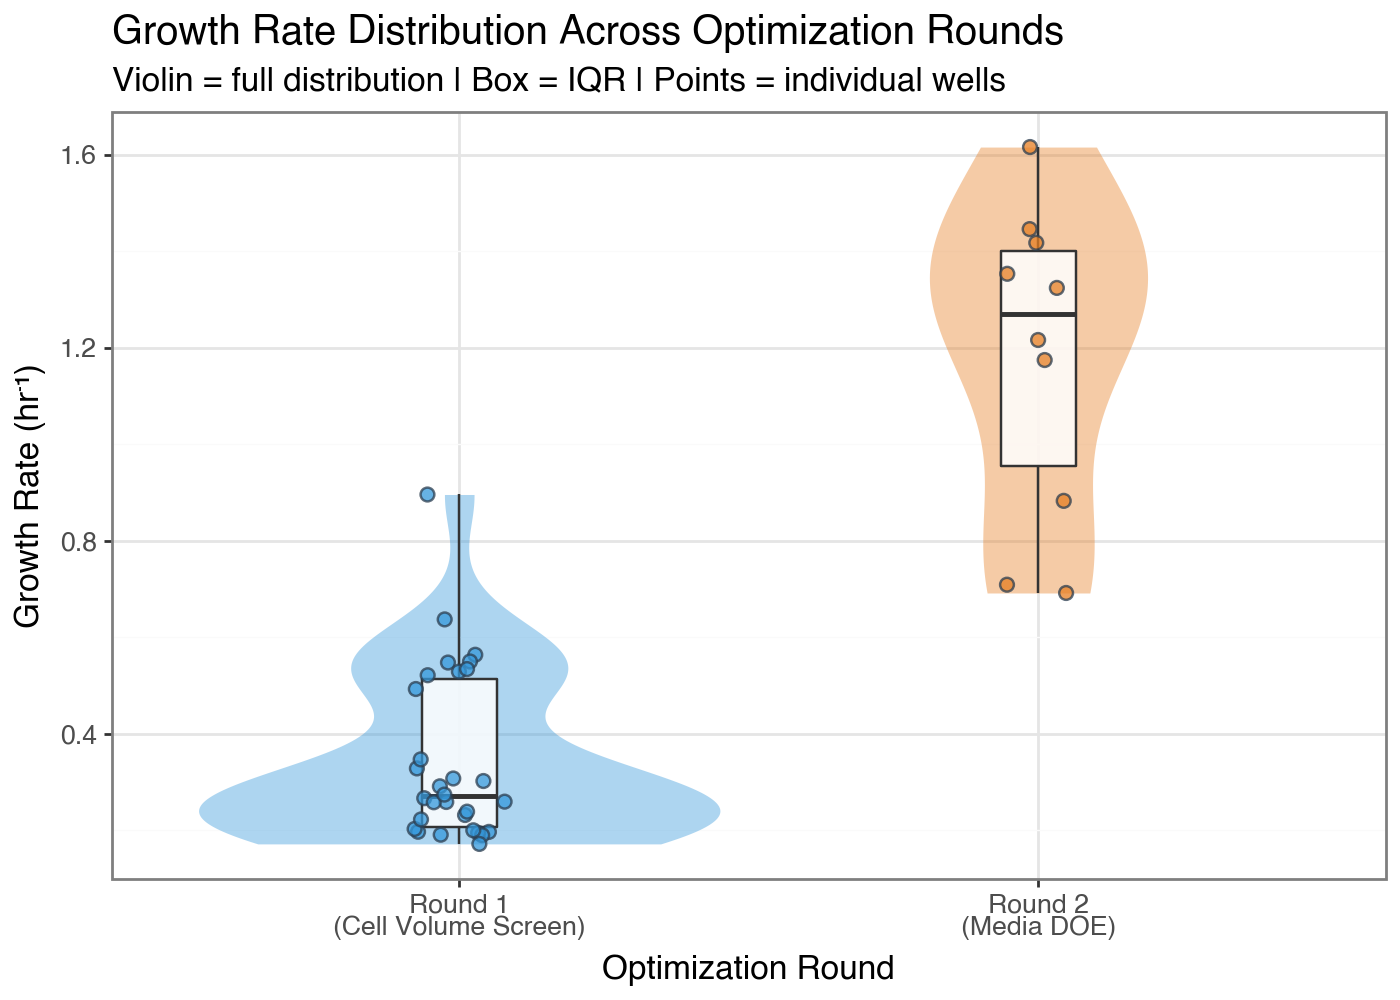

In [3]:
r1_growth['round'] = 'Round 1\n(Cell Volume Screen)'
r2_growth['round'] = 'Round 2\n(Media DOE)'

combined = pd.concat([
    r1_growth[['growth_rate_per_hr', 'round']],
    r2_growth[['growth_rate_per_hr', 'round']]
], ignore_index=True)

r1_med = r1_growth['growth_rate_per_hr'].median()
r2_med = r2_growth['growth_rate_per_hr'].median()
print(f"Round 1 median growth rate: {r1_med:.3f} hr⁻¹")
print(f"Round 2 median growth rate: {r2_med:.3f} hr⁻¹")
print(f"Fold improvement (median): {r2_med / r1_med:.2f}×")

(
    ggplot(combined, aes(x='round', y='growth_rate_per_hr', fill='round'))
    + geom_violin(alpha=0.4, color='none')
    + geom_boxplot(width=0.13, outlier_alpha=0, fill='white', alpha=0.85)
    + geom_jitter(width=0.08, alpha=0.75, size=2.3, color='#2c3e50')
    + scale_fill_manual(values={
        'Round 1\n(Cell Volume Screen)': '#3498db',
        'Round 2\n(Media DOE)':          '#e67e22'
    })
    + labs(
        title='Growth Rate Distribution Across Optimization Rounds',
        subtitle='Violin = full distribution | Box = IQR | Points = individual wells',
        x='Optimization Round',
        y='Growth Rate (hr⁻¹)'
    )
    + theme(legend_position='none', figure_size=(7, 5))
)

---
## Section 2: Round 1 Deep Dive – Cell Volume Screen

In Round 1, all wells used the same Novel Bio NBxCyclone media but varied the **media volume** (100–190 µL), which inversely controls the **cell seeding volume** (100–10 µL). Total well volume was fixed at 200 µL.

In [4]:
# reagent_volume_uL in Round 1 is the media volume (single reagent per well)
r1_growth['media_vol_uL'] = r1_growth['reagent_volume_uL']
r1_growth['cell_vol_uL']  = 200 - r1_growth['media_vol_uL']

# Per-condition summary (mean ± SD across 3 replicates)
r1_summary = (
    r1_growth
    .groupby('media_vol_uL')
    .agg(
        mean_gr    = ('growth_rate_per_hr',   'mean'),
        sd_gr      = ('growth_rate_per_hr',   'std'),
        mean_od    = ('max_absorbance_OD600',  'mean'),
        cell_vol   = ('cell_vol_uL',           'first')
    )
    .reset_index()
)
r1_summary['ymin'] = r1_summary['mean_gr'] - r1_summary['sd_gr']
r1_summary['ymax'] = r1_summary['mean_gr'] + r1_summary['sd_gr']

r1_summary.head(10)

,media_vol_uL,mean_gr,sd_gr,mean_od,cell_vol,ymin,ymax
0,100.0,0.500388,0.345208,0.970000,100.0,0.155180,0.845596
1,110.0,0.338221,0.149451,0.635800,90.0,0.188770,0.487672
2,120.0,0.256965,0.022603,0.765167,80.0,0.234362,0.279567
3,130.0,0.196026,0.006488,0.747633,70.0,0.189538,0.202515
4,140.0,0.186013,0.013018,0.762800,60.0,0.172995,0.199031
5,150.0,0.237431,0.047494,0.772300,50.0,0.189937,0.284925
6,160.0,0.251407,0.011383,0.718133,40.0,0.240024,0.262790
7,170.0,0.415095,0.191975,0.560900,30.0,0.223120,0.607070
8,180.0,0.539398,0.021764,0.297333,20.0,0.517634,0.561162
9,190.0,0.541771,0.011668,0.293000,10.0,0.530103,0.553440


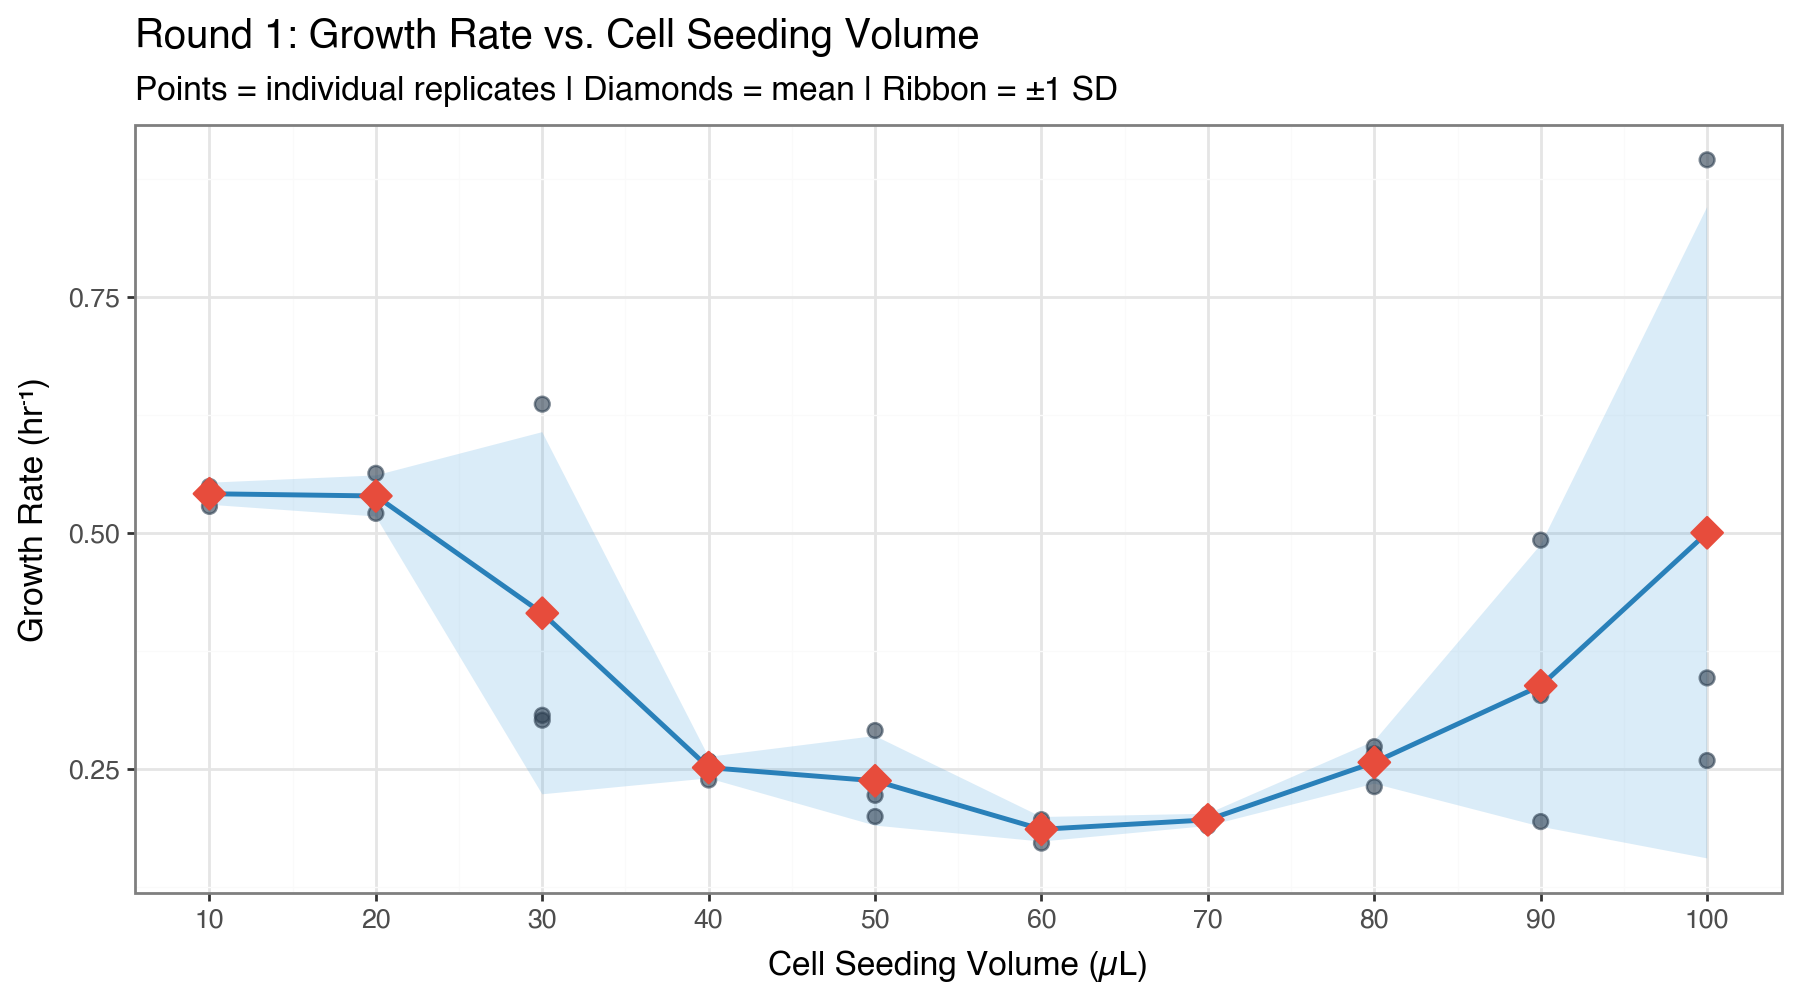

In [5]:
# Figure 2: Growth rate vs. cell seeding volume
(
    ggplot()
    + geom_ribbon(
        r1_summary,
        aes(x='cell_vol', ymin='ymin', ymax='ymax'),
        alpha=0.18, fill='#3498db'
    )
    + geom_line(
        r1_summary,
        aes(x='cell_vol', y='mean_gr'),
        color='#2980b9', size=1.0
    )
    + geom_point(
        r1_growth,
        aes(x='cell_vol_uL', y='growth_rate_per_hr'),
        color='#2c3e50', alpha=0.6, size=2.5
    )
    + geom_point(
        r1_summary,
        aes(x='cell_vol', y='mean_gr'),
        color='#e74c3c', size=4, shape='D'
    )
    + scale_x_continuous(breaks=list(range(10, 110, 10)))
    + labs(
        title='Round 1: Growth Rate vs. Cell Seeding Volume',
        subtitle='Points = individual replicates | Diamonds = mean | Ribbon = ±1 SD',
        x='Cell Seeding Volume (µL)',
        y='Growth Rate (hr⁻¹)'
    )
    + theme(figure_size=(9, 5))
)

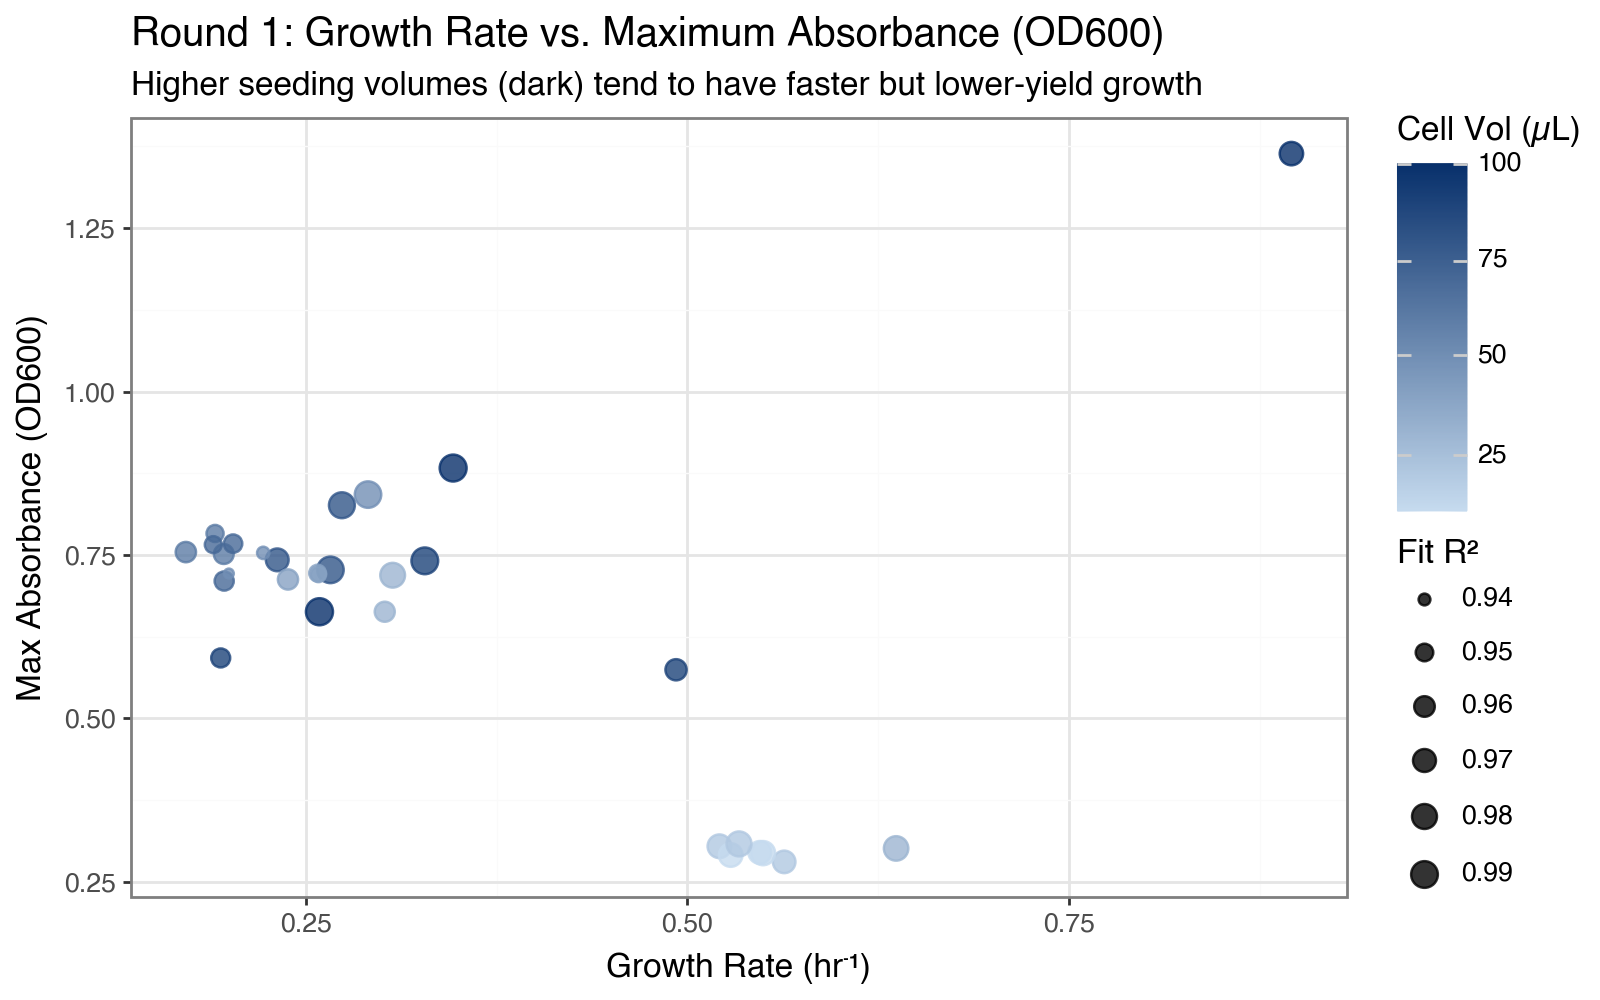

In [6]:
# Figure 3: Max OD600 vs. growth rate — growth-yield trade-off
(
    ggplot(r1_growth, aes(x='growth_rate_per_hr', y='max_absorbance_OD600',
                          color='cell_vol_uL', size='fit_r2'))
    + geom_point(alpha=0.8)
    + scale_color_gradient(low='#c6dbef', high='#08306b', name='Cell Vol (µL)')
    + scale_size_continuous(range=(1.5, 5), name='Fit R²')
    + labs(
        title='Round 1: Growth Rate vs. Maximum Absorbance (OD600)',
        subtitle='Higher seeding volumes (dark) tend to have faster but lower-yield growth',
        x='Growth Rate (hr⁻¹)',
        y='Max Absorbance (OD600)'
    )
    + theme(figure_size=(8, 5))
)

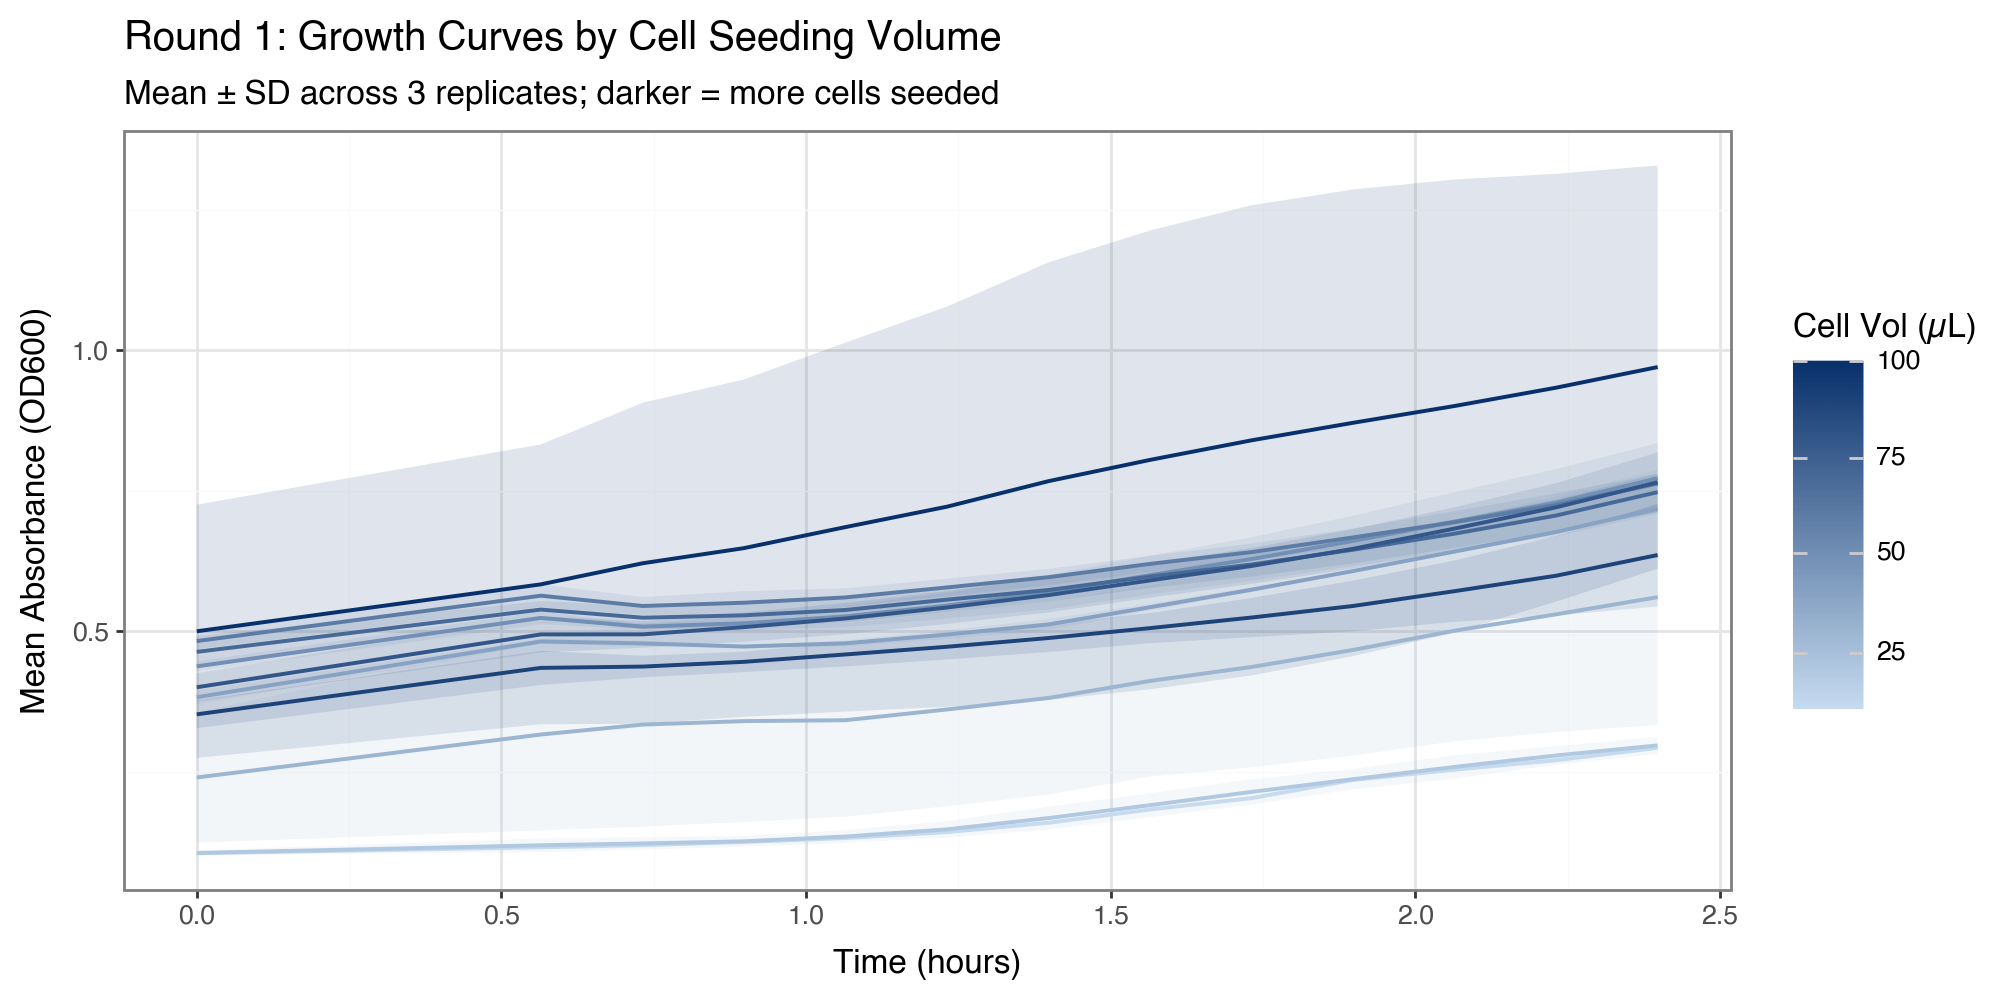

In [7]:
# Figure 4: Round 1 growth curves (mean across replicates)
r1_raw['timestamp'] = pd.to_datetime(r1_raw['observation_timestamp'])
r1_raw['hours']     = (r1_raw['timestamp'] - r1_raw['timestamp'].min()).dt.total_seconds() / 3600
r1_raw['cell_vol_uL'] = (200 - r1_raw['reagent_volume_uL']).astype(int)

r1_curves = (
    r1_raw
    .groupby(['cell_vol_uL', 'hours'])
    .agg(
        mean_od = ('absorbance_OD600', 'mean'),
        sd_od   = ('absorbance_OD600', 'std')
    )
    .reset_index()
)
r1_curves['sd_od']  = r1_curves['sd_od'].fillna(0)
r1_curves['ymin']   = r1_curves['mean_od'] - r1_curves['sd_od']
r1_curves['ymax']   = r1_curves['mean_od'] + r1_curves['sd_od']
r1_curves['cv_str'] = r1_curves['cell_vol_uL'].astype(str)  # for grouping

(
    ggplot(r1_curves, aes(x='hours', y='mean_od',
                          group='cv_str', color='cell_vol_uL'))
    + geom_ribbon(aes(ymin='ymin', ymax='ymax', fill='cell_vol_uL'),
                  alpha=0.12, color='none')
    + geom_line(size=0.8)
    + scale_color_gradient(low='#c6dbef', high='#08306b', name='Cell Vol (µL)')
    + scale_fill_gradient(low='#c6dbef', high='#08306b', name='Cell Vol (µL)')
    + labs(
        title='Round 1: Growth Curves by Cell Seeding Volume',
        subtitle='Mean ± SD across 3 replicates; darker = more cells seeded',
        x='Time (hours)',
        y='Mean Absorbance (OD600)'
    )
    + theme(figure_size=(10, 5))
)

---
## Section 3: Round 2 Deep Dive – Media DOE

Round 2 tested three media families, each with different supplementary reagent concentrations:
- **SD (Semi-Defined)**: Semi-Defined base + MOPS, Tryptone, Yeast Extract (± Water)
- **HB (High Buffer Defined)**: High Buffer Defined base + Na L-Glutamate, Tryptone, Yeast Extract, Water
- **LB (LB-based)**: LBv2 base + MOPS, KH₂PO₄, Glucose, Water
- **Baseline**: Novel Bio Cyclone (same media family as Round 1)

In [8]:
def get_media_type(cid):
    if cid.startswith('baseline'):
        return 'Baseline (Novel Bio Cyclone)'
    prefix = cid.split('-')[0]
    if prefix == 'SD':
        return 'Semi-Defined'
    elif prefix == 'HB':
        return 'High Buffer Defined'
    elif prefix == 'LB':
        return 'LB-based'
    return cid

r2_growth['media_type']       = r2_growth['condition_id'].apply(get_media_type)
r2_growth['condition_label']  = r2_growth['condition_id'].str.rsplit('_', n=1).str[0]

# Sort by growth rate for ranked display
r2_sorted = r2_growth.sort_values('growth_rate_per_hr', ascending=False).reset_index(drop=True)
r2_sorted['condition_label'] = pd.Categorical(
    r2_sorted['condition_label'],
    categories=r2_sorted['condition_label'].tolist(),
    ordered=True
)

print(r2_sorted[['condition_label', 'media_type', 'growth_rate_per_hr',
                  'max_absorbance_OD600', 't_inflection_hours']].to_string(index=False))

condition_label                   media_type  growth_rate_per_hr  max_absorbance_OD600  t_inflection_hours
           HB-1          High Buffer Defined            1.616133                0.4545              0.8797
           SD-1                 Semi-Defined            1.446114                0.4924              0.9236
           SD-2                 Semi-Defined            1.417635                0.4581              0.9741
           SD-3                 Semi-Defined            1.353330                0.5020              1.1018
           HB-2          High Buffer Defined            1.324148                0.4869              1.1989
       baseline Baseline (Novel Bio Cyclone)            1.216110                0.3434              1.0444
           HB-3          High Buffer Defined            1.174552                0.5028              1.4917
           LB-2                     LB-based            0.882567                0.3921              3.0347
           LB-3                     L

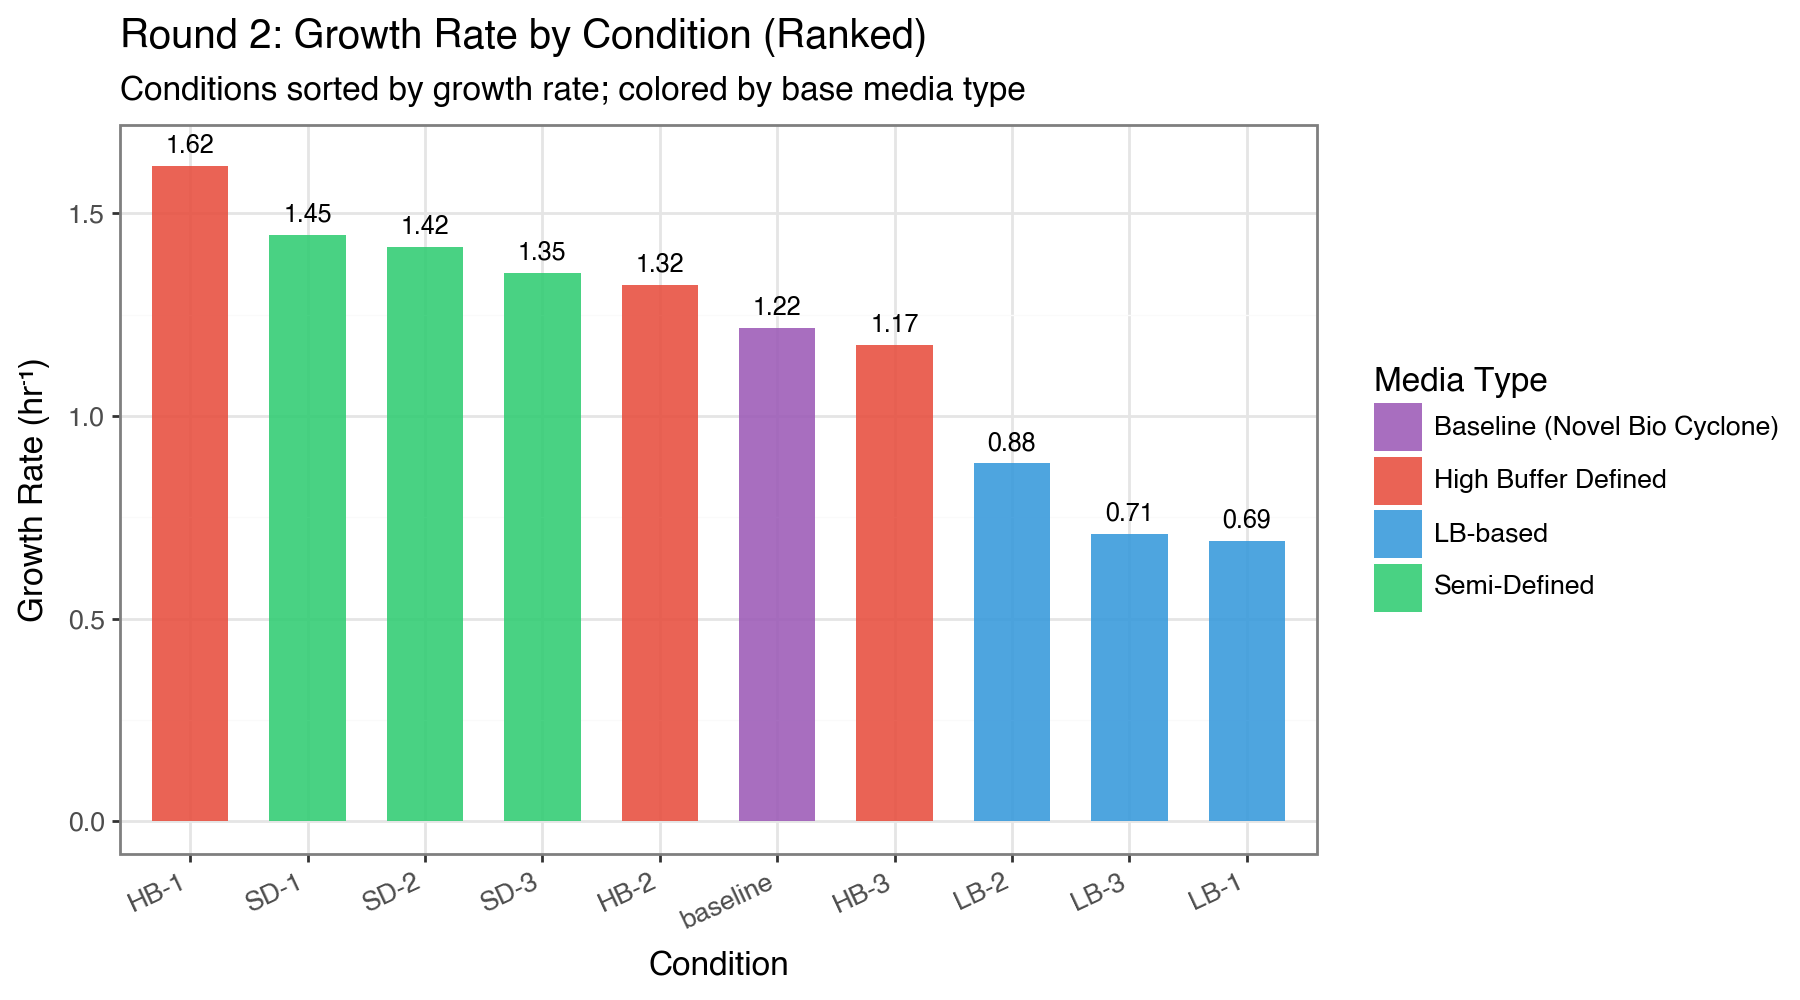

In [9]:
# Figure 5: Growth rates by condition, colored by media type
(
    ggplot(r2_sorted, aes(x='condition_label', y='growth_rate_per_hr', fill='media_type'))
    + geom_col(width=0.65, alpha=0.87)
    + geom_text(
        aes(label='growth_rate_per_hr'),
        format_string='{:.2f}',
        va='bottom', size=9, nudge_y=0.02
    )
    + scale_fill_manual(values=MEDIA_COLORS, name='Media Type')
    + labs(
        title='Round 2: Growth Rate by Condition (Ranked)',
        subtitle='Conditions sorted by growth rate; colored by base media type',
        x='Condition',
        y='Growth Rate (hr⁻¹)'
    )
    + theme(figure_size=(9, 5), axis_text_x=element_text(angle=25, hjust=1))
)

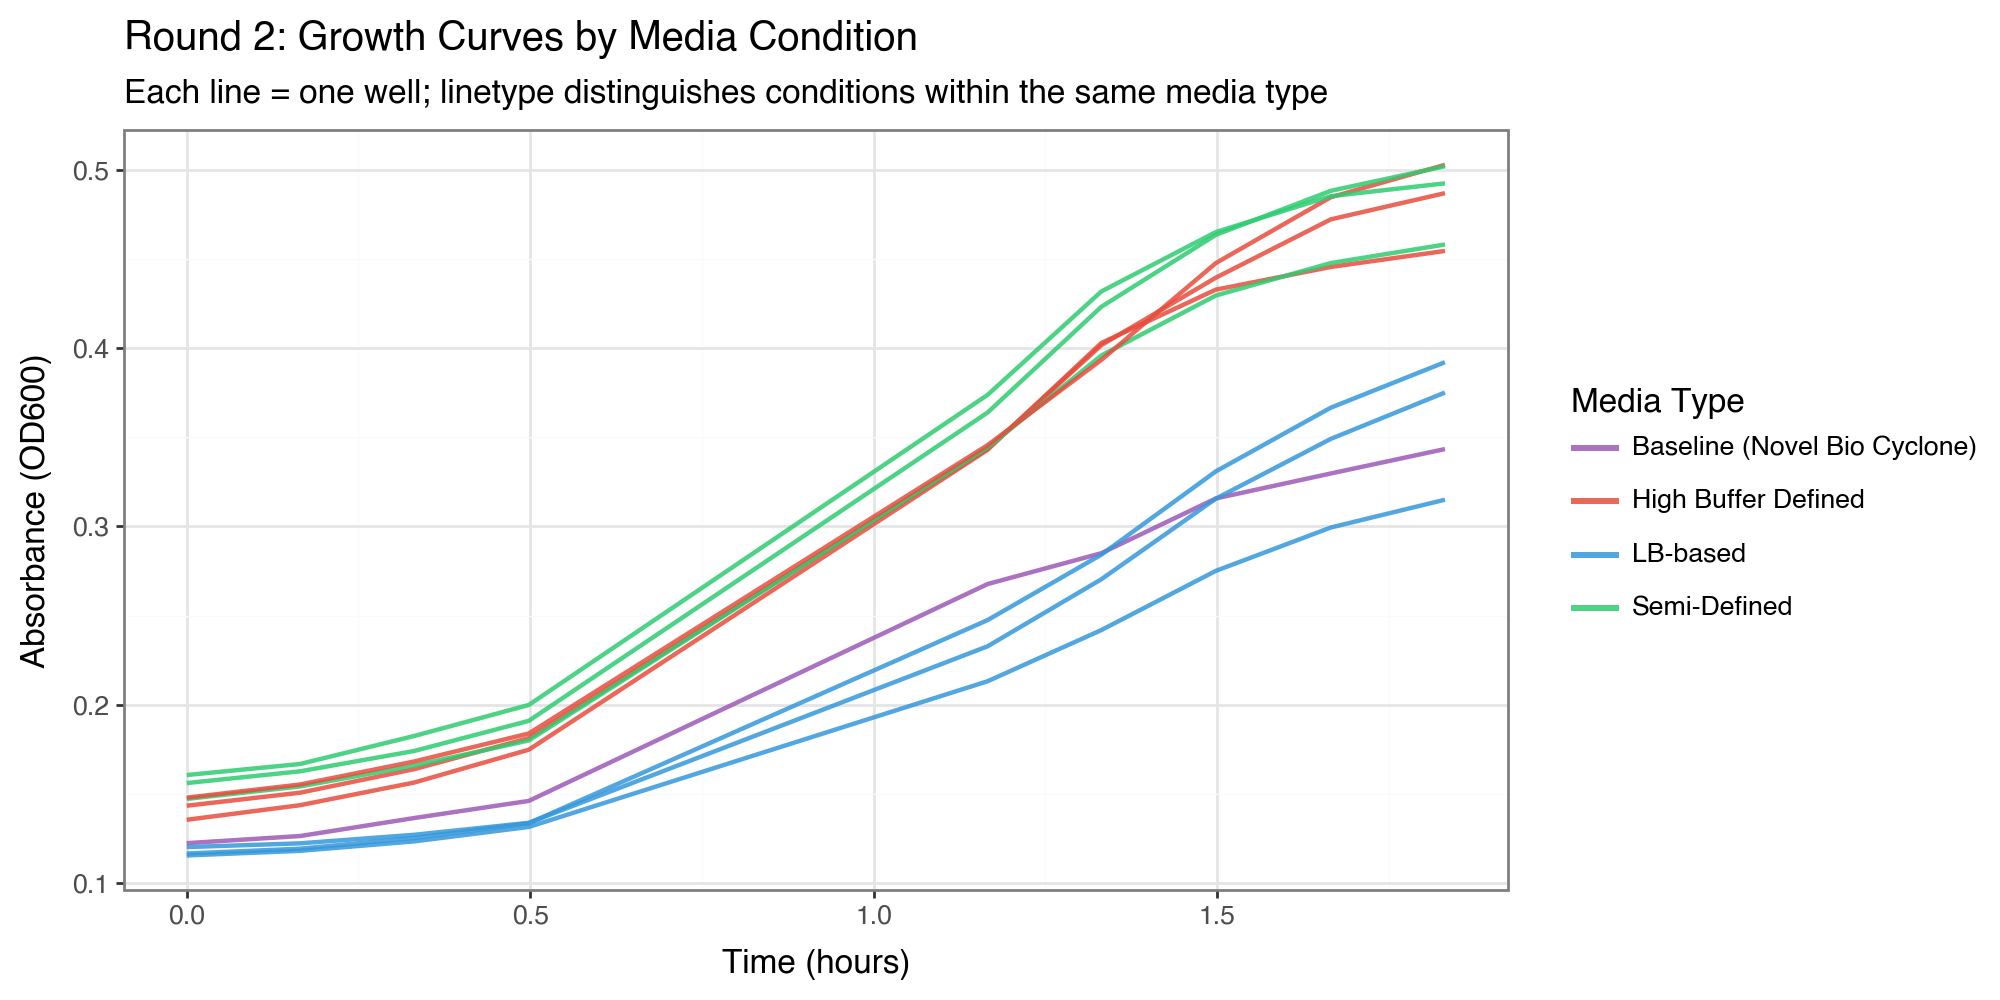

In [ ]:
# Figure 6: Round 2 growth curves
r2_raw['timestamp'] = pd.to_datetime(r2_raw['observation_timestamp'])
r2_dedup = r2_raw.drop_duplicates(subset=['culture_id', 'observation_timestamp']).copy()
r2_dedup['hours']      = (r2_dedup['timestamp'] - r2_dedup['timestamp'].min()).dt.total_seconds() / 3600
r2_dedup['media_type'] = r2_dedup['condition_id'].apply(get_media_type)

(
    ggplot(r2_dedup, aes(x='hours', y='absorbance_OD600',
                         group='culture_id', color='media_type'))
    + geom_line(size=0.9, alpha=0.85)
    + scale_color_manual(values=MEDIA_COLORS, name='Media Type')
    + labs(
        title='Round 2: Growth Curves by Media Condition',
        subtitle='Each line = one media type',
        x='Time (hours)',
        y='Absorbance (OD600)',
        linetype='Condition'
    )
    + theme(figure_size=(10, 5))
)

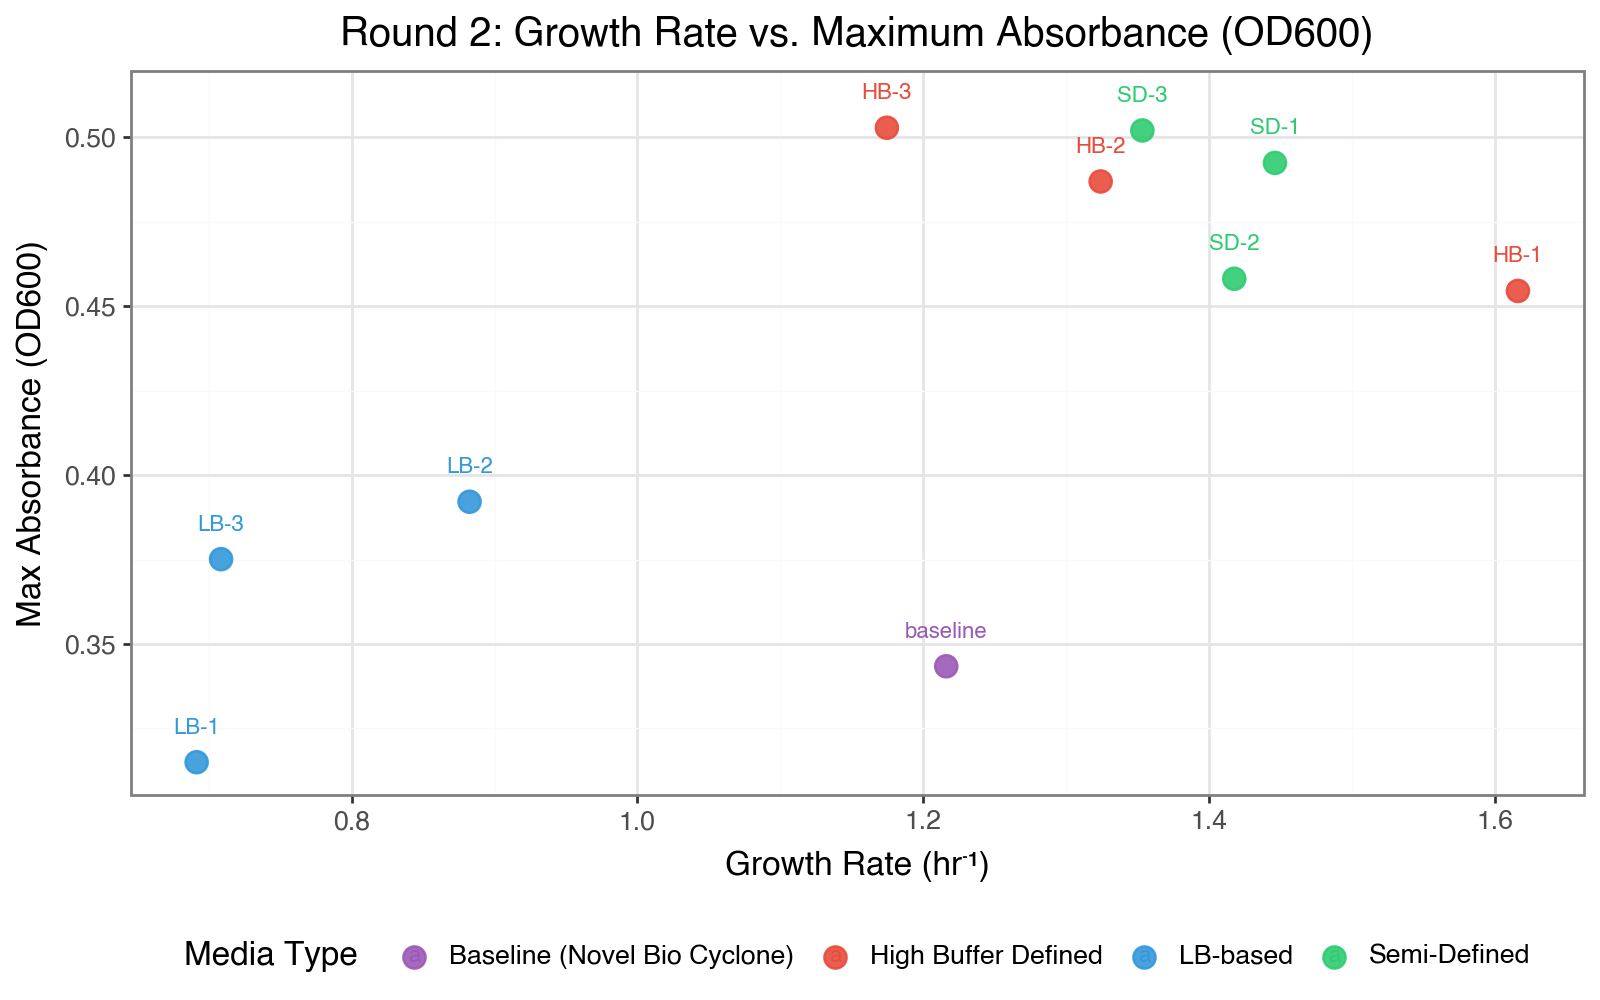

In [11]:
# Figure 7: Max OD600 vs. growth rate for Round 2
(
    ggplot(r2_growth, aes(x='growth_rate_per_hr', y='max_absorbance_OD600',
                          color='media_type', label='condition_label'))
    + geom_point(size=4, alpha=0.9)
    + geom_text(nudge_y=0.007, size=8, va='bottom')
    + scale_color_manual(values=MEDIA_COLORS, name='Media Type')
    + labs(
        title='Round 2: Growth Rate vs. Maximum Absorbance (OD600)',
        x='Growth Rate (hr⁻¹)',
        y='Max Absorbance (OD600)'
    )
    + theme(figure_size=(8, 5), legend_position='bottom')
)

---
## Section 4: Cross-Round Comparison

Ranking all conditions from both rounds to assess the improvement achieved by the DOE approach.

In [12]:
# Build a unified comparison table
# Round 1: use per-condition means from r1_reps
r1_reps['cond_num']        = r1_reps['condition_id'].str.split('_').str[1].astype(int)
r1_reps['media_vol_uL']    = 90 + r1_reps['cond_num'] * 10
r1_reps['cell_vol_uL']     = 200 - r1_reps['media_vol_uL']
r1_reps['condition_label'] = r1_reps['cell_vol_uL'].astype(str) + 'µL cells'
r1_reps['media_type']      = 'Baseline (Novel Bio Cyclone)'
r1_reps['round']           = 'Round 1'

r1_for_cmp = r1_reps[['condition_label', 'media_type', 'round',
                        'mean_growth_rate_per_hr']].rename(
    columns={'mean_growth_rate_per_hr': 'growth_rate_per_hr'})

# Round 2: individual values
r2_for_cmp = r2_growth[['condition_label', 'media_type', 'growth_rate_per_hr']].copy()
r2_for_cmp['round'] = 'Round 2'

all_cmp = pd.concat([r1_for_cmp, r2_for_cmp], ignore_index=True)
all_cmp = all_cmp.sort_values('growth_rate_per_hr', ascending=True).reset_index(drop=True)
all_cmp['condition_label'] = pd.Categorical(
    all_cmp['condition_label'],
    categories=all_cmp['condition_label'].tolist(),
    ordered=True
)
all_cmp['zero'] = 0

print("Top 5 conditions overall:")
print(all_cmp.sort_values('growth_rate_per_hr', ascending=False)[
    ['condition_label', 'media_type', 'round', 'growth_rate_per_hr']
].head(5).to_string(index=False))

Top 5 conditions overall:
condition_label          media_type   round  growth_rate_per_hr
           HB-1 High Buffer Defined Round 2            1.616133
           SD-1        Semi-Defined Round 2            1.446114
           SD-2        Semi-Defined Round 2            1.417635
           SD-3        Semi-Defined Round 2            1.353330
           HB-2 High Buffer Defined Round 2            1.324148


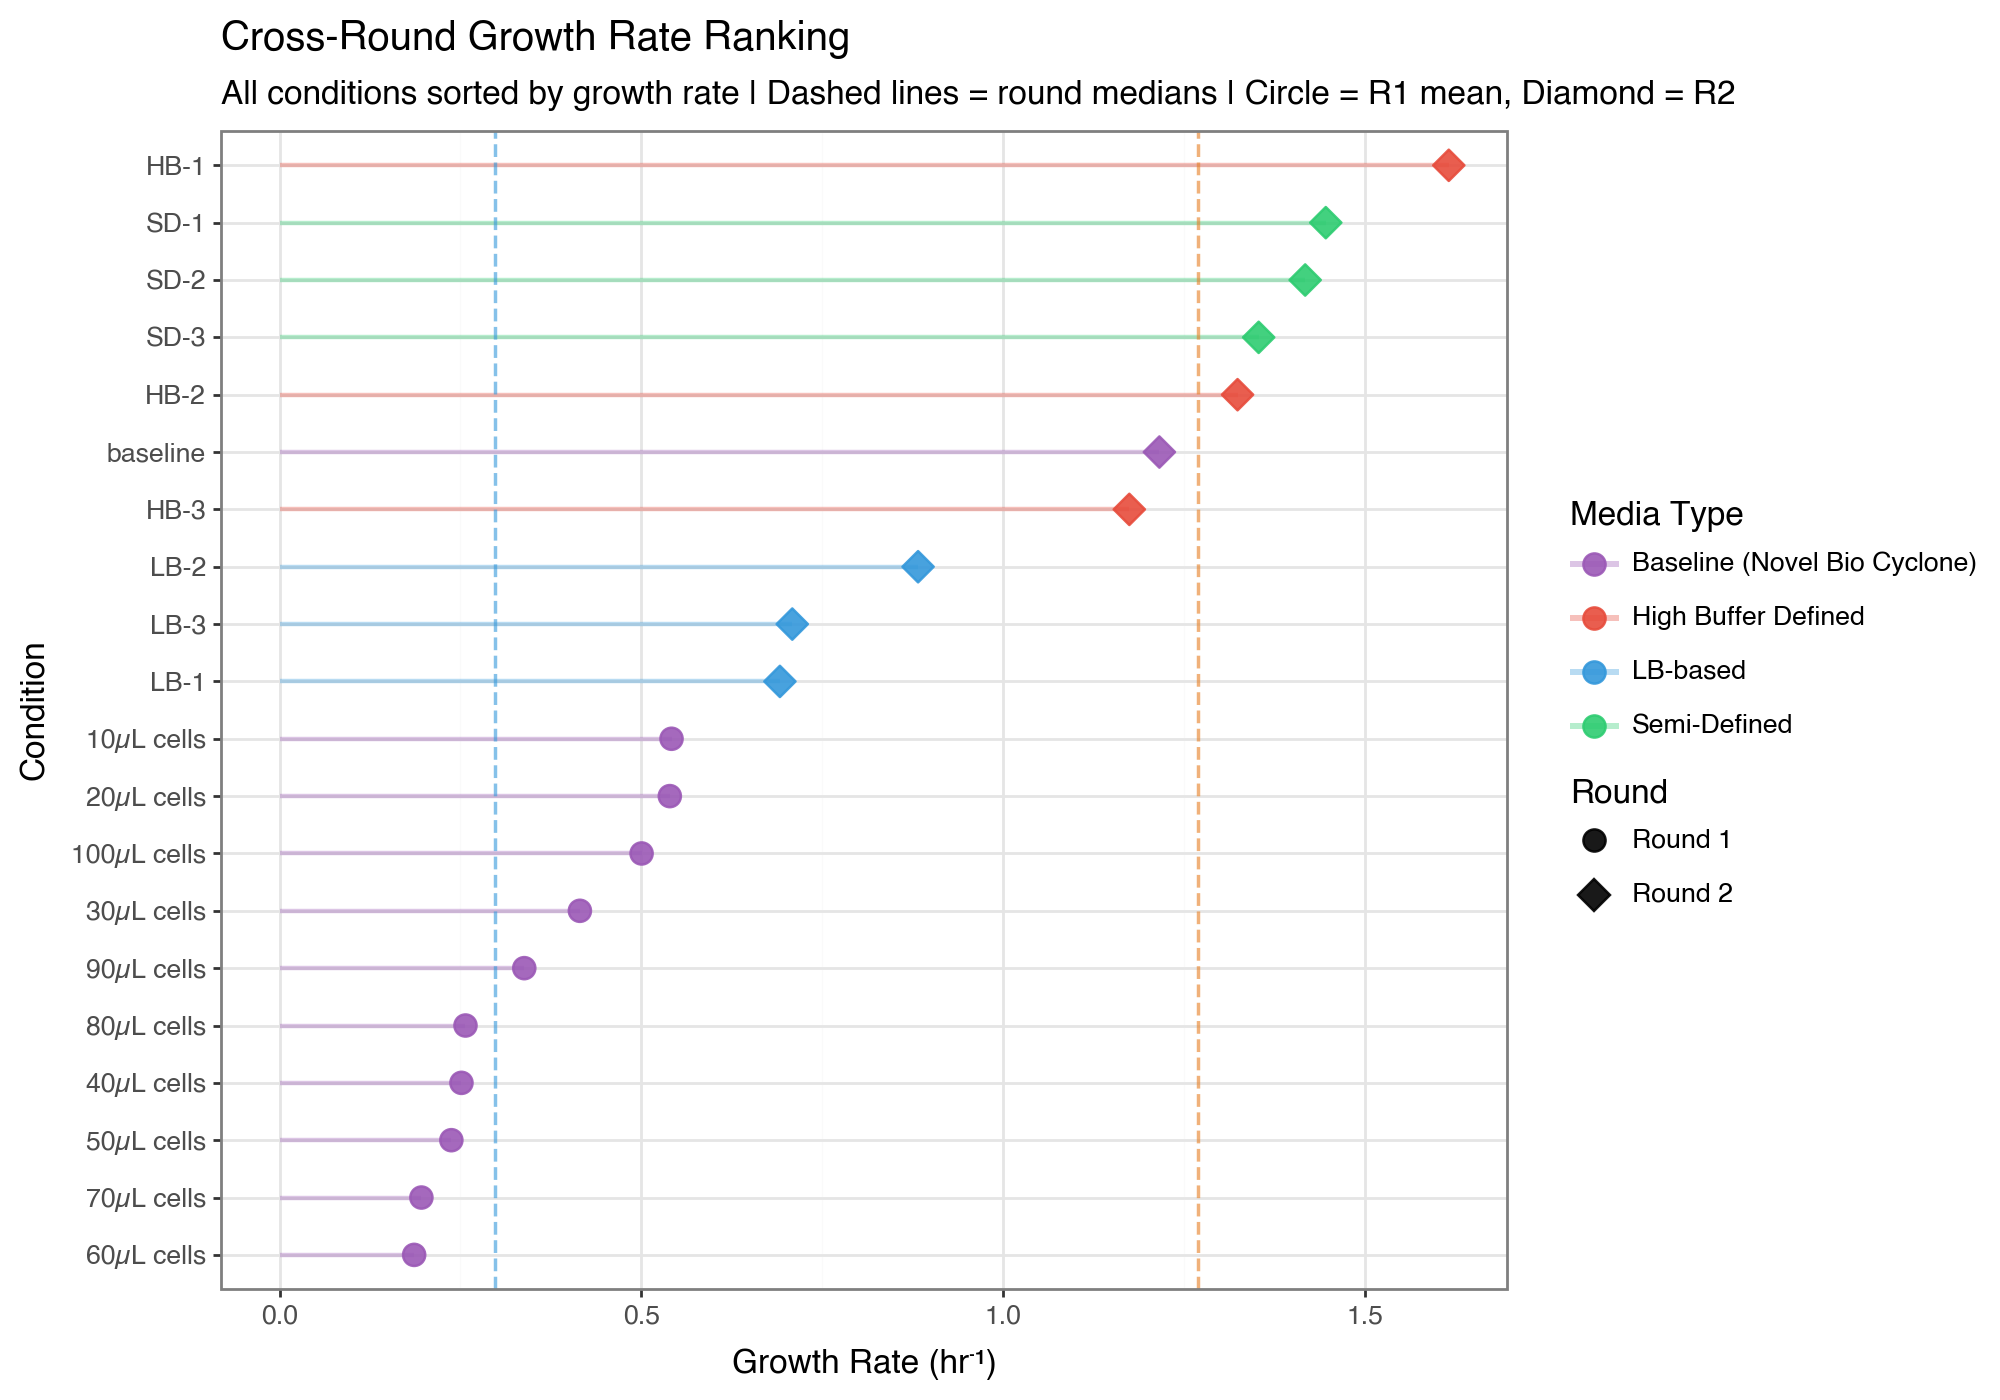

In [13]:
# Figure 8: Cross-round growth rate ranking (lollipop chart)
(
    ggplot(all_cmp, aes(y='condition_label', x='growth_rate_per_hr', color='media_type'))
    + geom_segment(
        aes(x='zero', xend='growth_rate_per_hr', yend='condition_label'),
        alpha=0.35, size=0.9
    )
    + geom_point(aes(shape='round'), size=4, alpha=0.9)
    + geom_vline(
        xintercept=r1_reps['mean_growth_rate_per_hr'].median(),
        linetype='dashed', color='#3498db', alpha=0.6, size=0.7
    )
    + geom_vline(
        xintercept=r2_growth['growth_rate_per_hr'].median(),
        linetype='dashed', color='#e67e22', alpha=0.6, size=0.7
    )
    + scale_color_manual(values=MEDIA_COLORS, name='Media Type')
    + scale_shape_manual(values={'Round 1': 'o', 'Round 2': 'D'}, name='Round')
    + labs(
        title='Cross-Round Growth Rate Ranking',
        subtitle='All conditions sorted by growth rate | Dashed lines = round medians | Circle = R1 mean, Diamond = R2',
        x='Growth Rate (hr⁻¹)',
        y='Condition'
    )
    + theme(figure_size=(10, 7))
)

In [14]:
# Summary statistics table
summary = (
    all_cmp
    .groupby(['round', 'media_type'])
    .agg(
        n_conditions   = ('growth_rate_per_hr', 'count'),
        mean_gr        = ('growth_rate_per_hr', 'mean'),
        median_gr      = ('growth_rate_per_hr', 'median'),
        max_gr         = ('growth_rate_per_hr', 'max'),
        min_gr         = ('growth_rate_per_hr', 'min')
    )
    .reset_index()
    .sort_values(['round', 'mean_gr'], ascending=[True, False])
)
summary.columns = ['Round', 'Media Type', 'N', 'Mean GR', 'Median GR', 'Max GR', 'Min GR']
for col in ['Mean GR', 'Median GR', 'Max GR', 'Min GR']:
    summary[col] = summary[col].round(3)
summary

,Round,Media Type,N,Mean GR,Median GR,Max GR,Min GR
0,Round 1,Baseline (Novel Bio Cyclone),10,0.346,0.298,0.542,0.186
4,Round 2,Semi-Defined,3,1.406,1.418,1.446,1.353
2,Round 2,High Buffer Defined,3,1.372,1.324,1.616,1.175
1,Round 2,Baseline (Novel Bio Cyclone),1,1.216,1.216,1.216,1.216
3,Round 2,LB-based,3,0.761,0.709,0.883,0.692


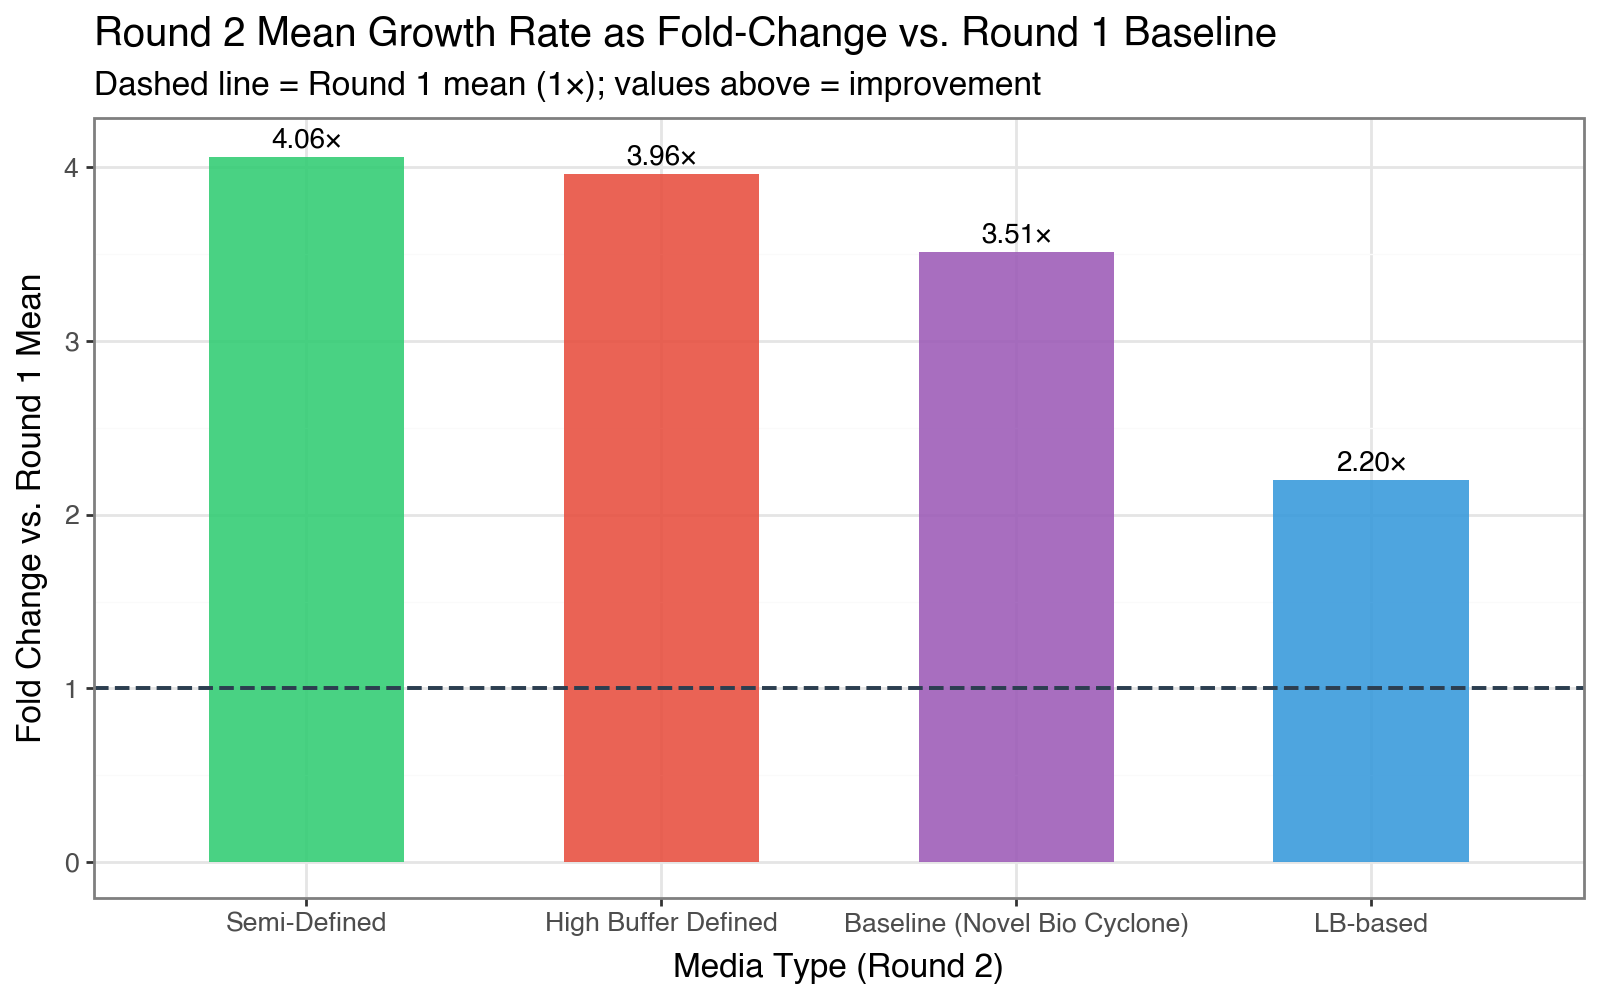

In [15]:
# Figure 9: Growth rate improvement from Round 1 → Round 2
# Compare R1 mean baseline vs R2 per-media-type mean
r1_baseline_mean = r1_reps['mean_growth_rate_per_hr'].mean()

r2_by_media = (
    r2_growth
    .groupby('media_type')
    .agg(mean_gr=('growth_rate_per_hr', 'mean'))
    .reset_index()
)
r2_by_media['fold_vs_r1'] = r2_by_media['mean_gr'] / r1_baseline_mean
r2_by_media = r2_by_media.sort_values('fold_vs_r1', ascending=False)
r2_by_media['media_type'] = pd.Categorical(
    r2_by_media['media_type'],
    categories=r2_by_media['media_type'].tolist(),
    ordered=True
)

(
    ggplot(r2_by_media, aes(x='media_type', y='fold_vs_r1', fill='media_type'))
    + geom_col(width=0.55, alpha=0.87)
    + geom_hline(yintercept=1.0, linetype='dashed', color='#2c3e50', size=0.8)
    + geom_text(
        aes(label='fold_vs_r1'),
        format_string='{:.2f}×',
        va='bottom', size=10, nudge_y=0.02
    )
    + scale_fill_manual(values=MEDIA_COLORS)
    + labs(
        title='Round 2 Mean Growth Rate as Fold-Change vs. Round 1 Baseline',
        subtitle='Dashed line = Round 1 mean (1×); values above = improvement',
        x='Media Type (Round 2)',
        y='Fold Change vs. Round 1 Mean'
    )
    + theme(legend_position='none', figure_size=(8, 5))
)

---
## Conclusions

### Round 1 (Cell Volume Screen)
- Growth rate shows a **non-linear relationship** with cell seeding volume. Very low seeding (10–20 µL cells) and high seeding (100 µL cells) both yield higher apparent growth rates, while mid-range seeding (40–70 µL) gives slower growth. This likely reflects different lag phase dynamics rather than true maximum growth rate differences.
- Higher cell seeding volumes tend to produce **lower final OD600**, consistent with faster consumption of limited nutrients.
- Replicate variability (R²) was generally good (>0.94), indicating reliable sigmoid fits.

### Round 2 (Media DOE)
- **High Buffer Defined (HB-1)** achieved the highest growth rate at **1.62 hr⁻¹**, more than 4× the Round 1 average.
- **Semi-Defined (SD)** conditions performed consistently well (~1.35–1.45 hr⁻¹), suggesting this media family is broadly supportive of rapid growth.
- **LB-based** conditions underperformed relative to other Round 2 conditions (~0.69–0.88 hr⁻¹), though they still matched or exceeded most Round 1 conditions.
- Notably, the **Round 2 Novel Bio Cyclone baseline** (1.22 hr⁻¹) was substantially faster than any Round 1 condition, likely reflecting different experimental parameters (e.g., cell passage, initial density).

### Recommended Next Steps
1. **Follow up on HB-1**: Replicate and optimize the High Buffer Defined + Na L-Glutamate + Tryptone + Yeast Extract formulation (HB-1: 110/10/26/14/20 µL) with additional replicates.
2. **Replicate SD conditions**: SD-1 and SD-2 showed high growth rates with modest variability — worth confirming with triplicates.
3. **Investigate the baseline discrepancy** between rounds to understand whether cell state or media lot differences are contributing to the shift.
4. **Round 3 DOE**: Consider a response surface design around the HB and SD media optima to fine-tune reagent concentrations.
